# Default Plotting

Plotting in HiCONA is based on `coolbox`, a package which allows to create and combine custom genomic tracks for chromatin conformation data. HiCONA provides its custom tracks for modular plotting (see the **Custom Plotting** notebook), but also provides some predefined combinations of tracks which should cover the most common cases. By using these presets, you lose some flexibility but you can gain a lot in terms of speed.

In [1]:
import coolbox.api as ca
import hicona as hi
import hicona.plotting as hp

TABLE_PATH = "../data/IMR90_chr17_clustered_table/"
REGION = "chr17:0-10000000"

table = hi.PixelTable.load(TABLE_PATH)

## Table plotting

Plotting always starts from a `PixelTable` instance (or more of them) which is passed to a plotting function with a combination of other parameters. The most basic case would be plotting the contact matrix as is, in its typical square or triangular shape.

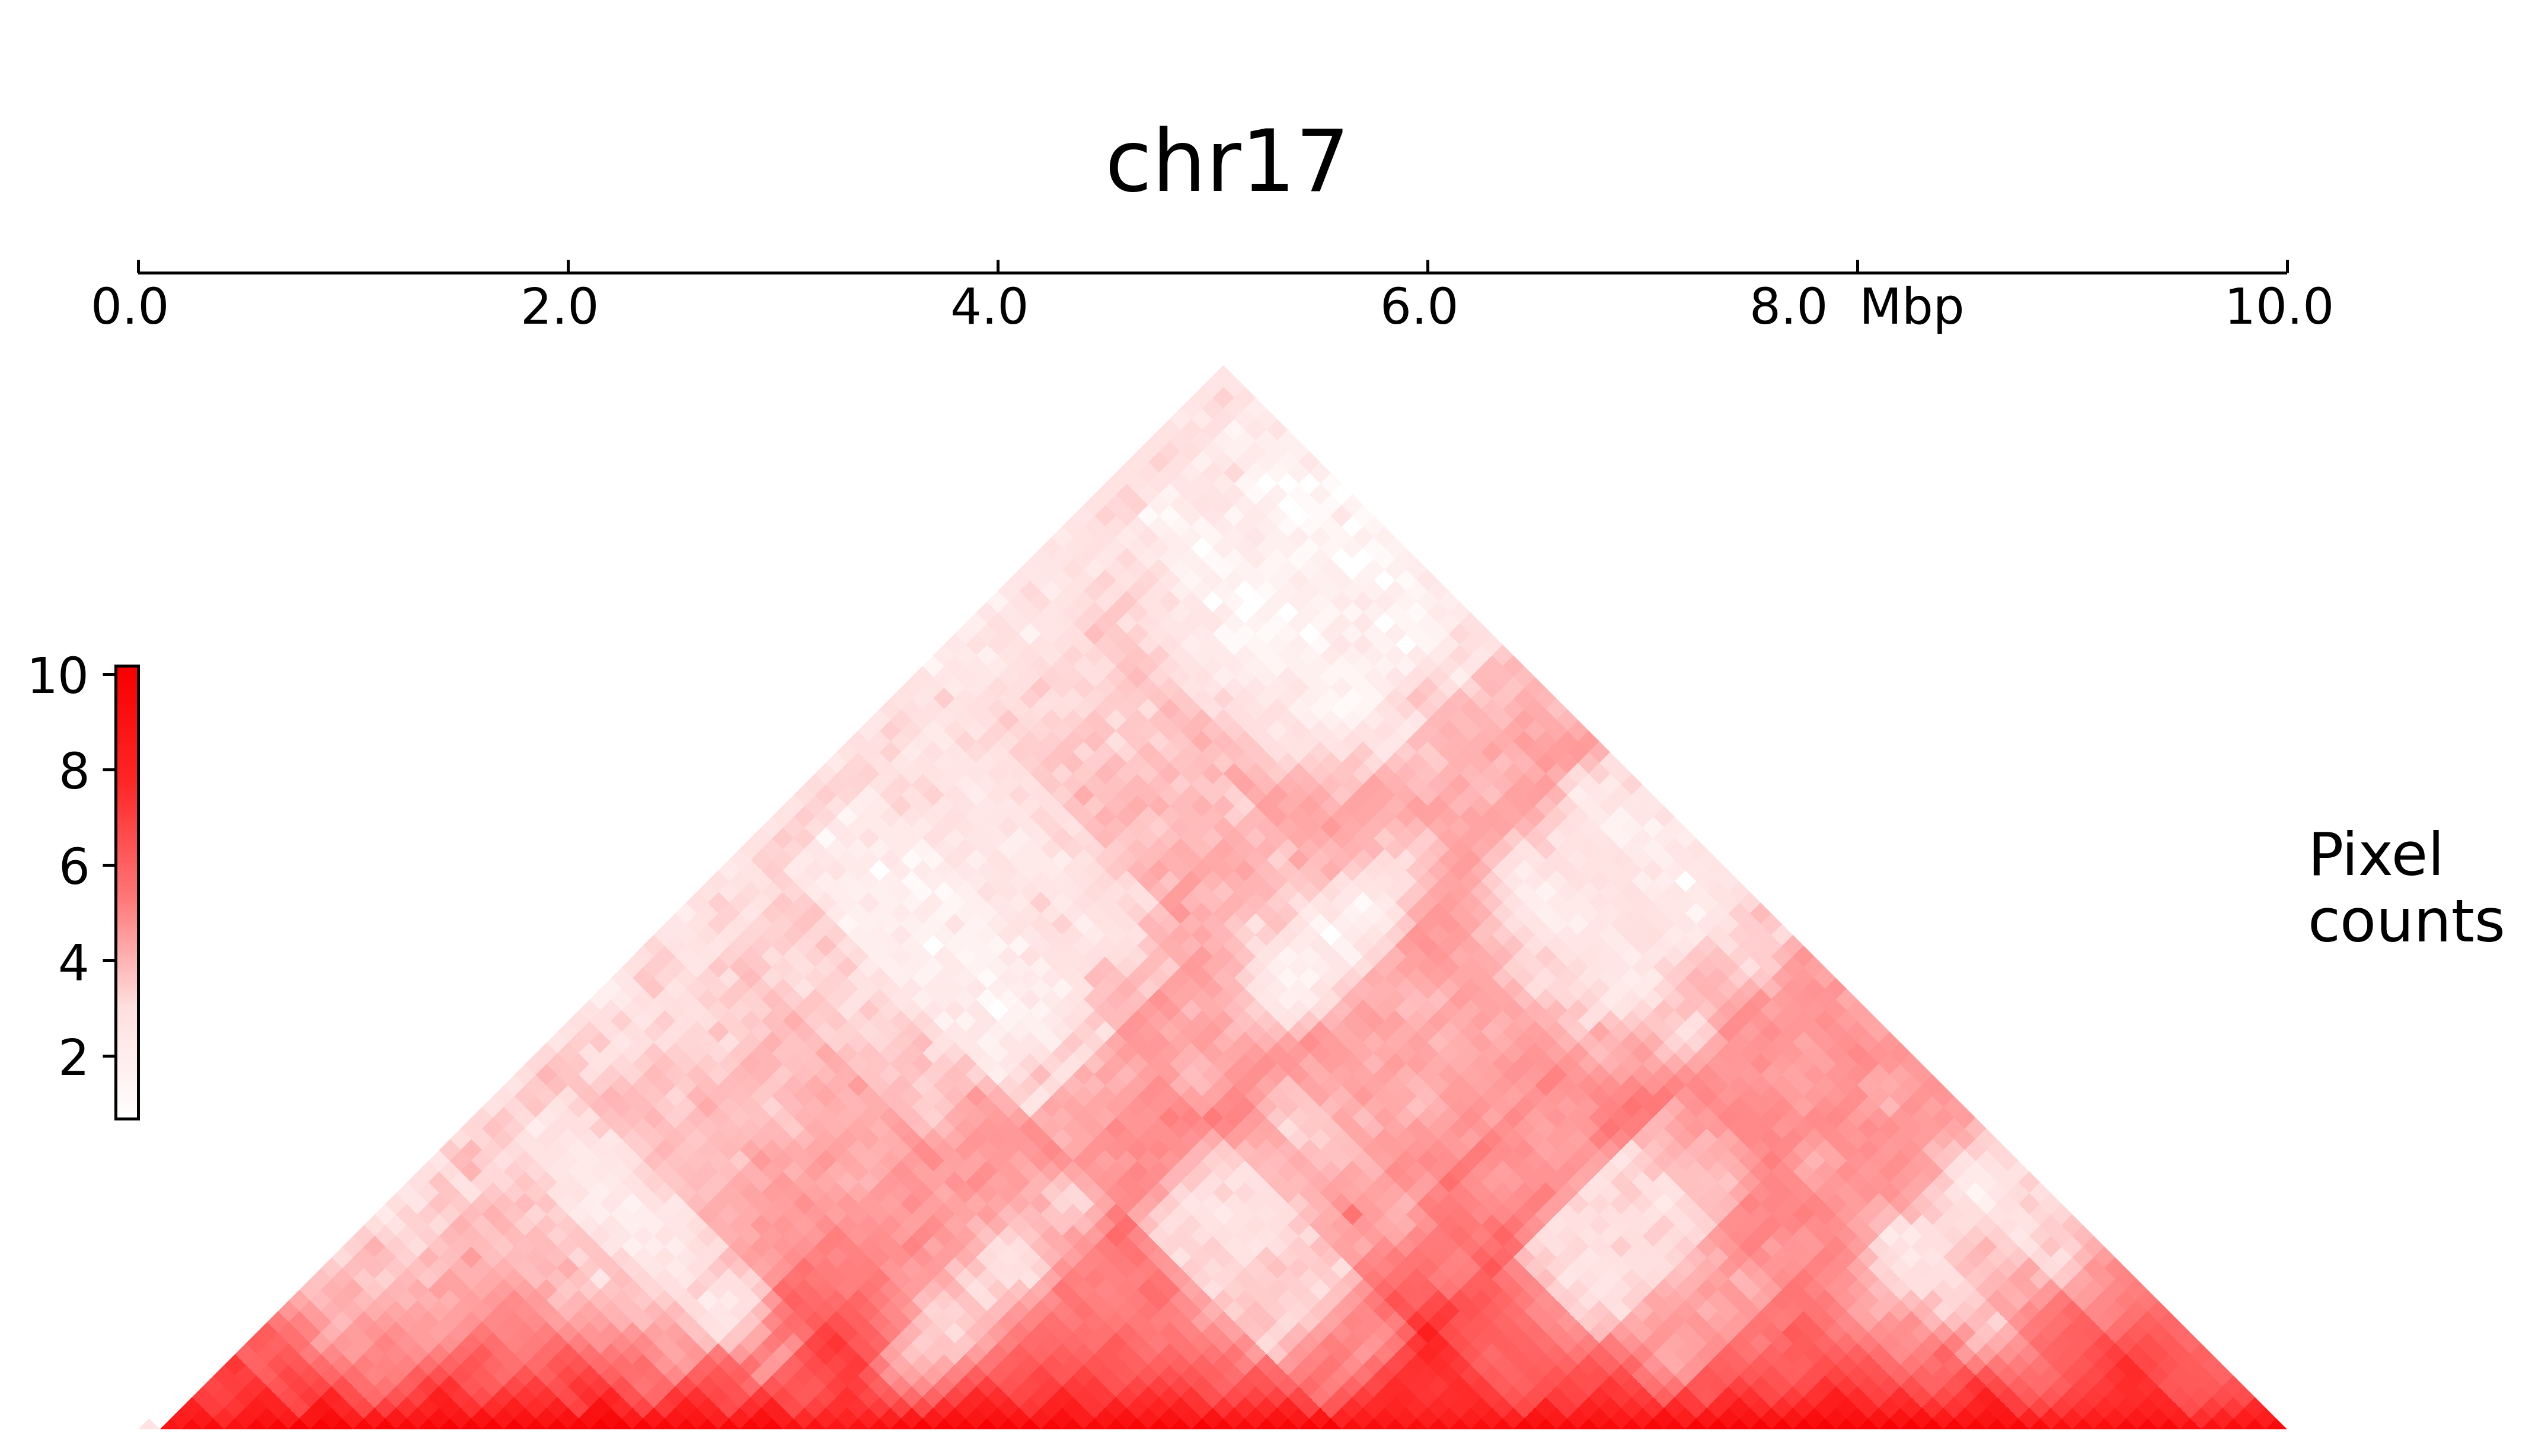

In [2]:
hp.plot_table(table, REGION, modality="triangular", depth_ratio=1)  # Use `modality=matrix` for a square matrix.

<div class="alert alert-info">

Note

Actually, `coolbox` (and by extension HiCONA), provides a third plotting style, called `window` which is similar to `triangular` but does not crop data outside of the desired region if it would fall within the plot area. For more information check out `coolbox` documentation.
</div>


This is the very base case, which still allows for some customization. As an example, you might think that the triangular plot takes up more space than needed, with the top of the triangle causing a lot of white space for mostly empty pixels (this is especially the case at high distances and low bin size). You can pass the `depth_ratio` argument to "cut" the matrix at a desired fraction of the height.

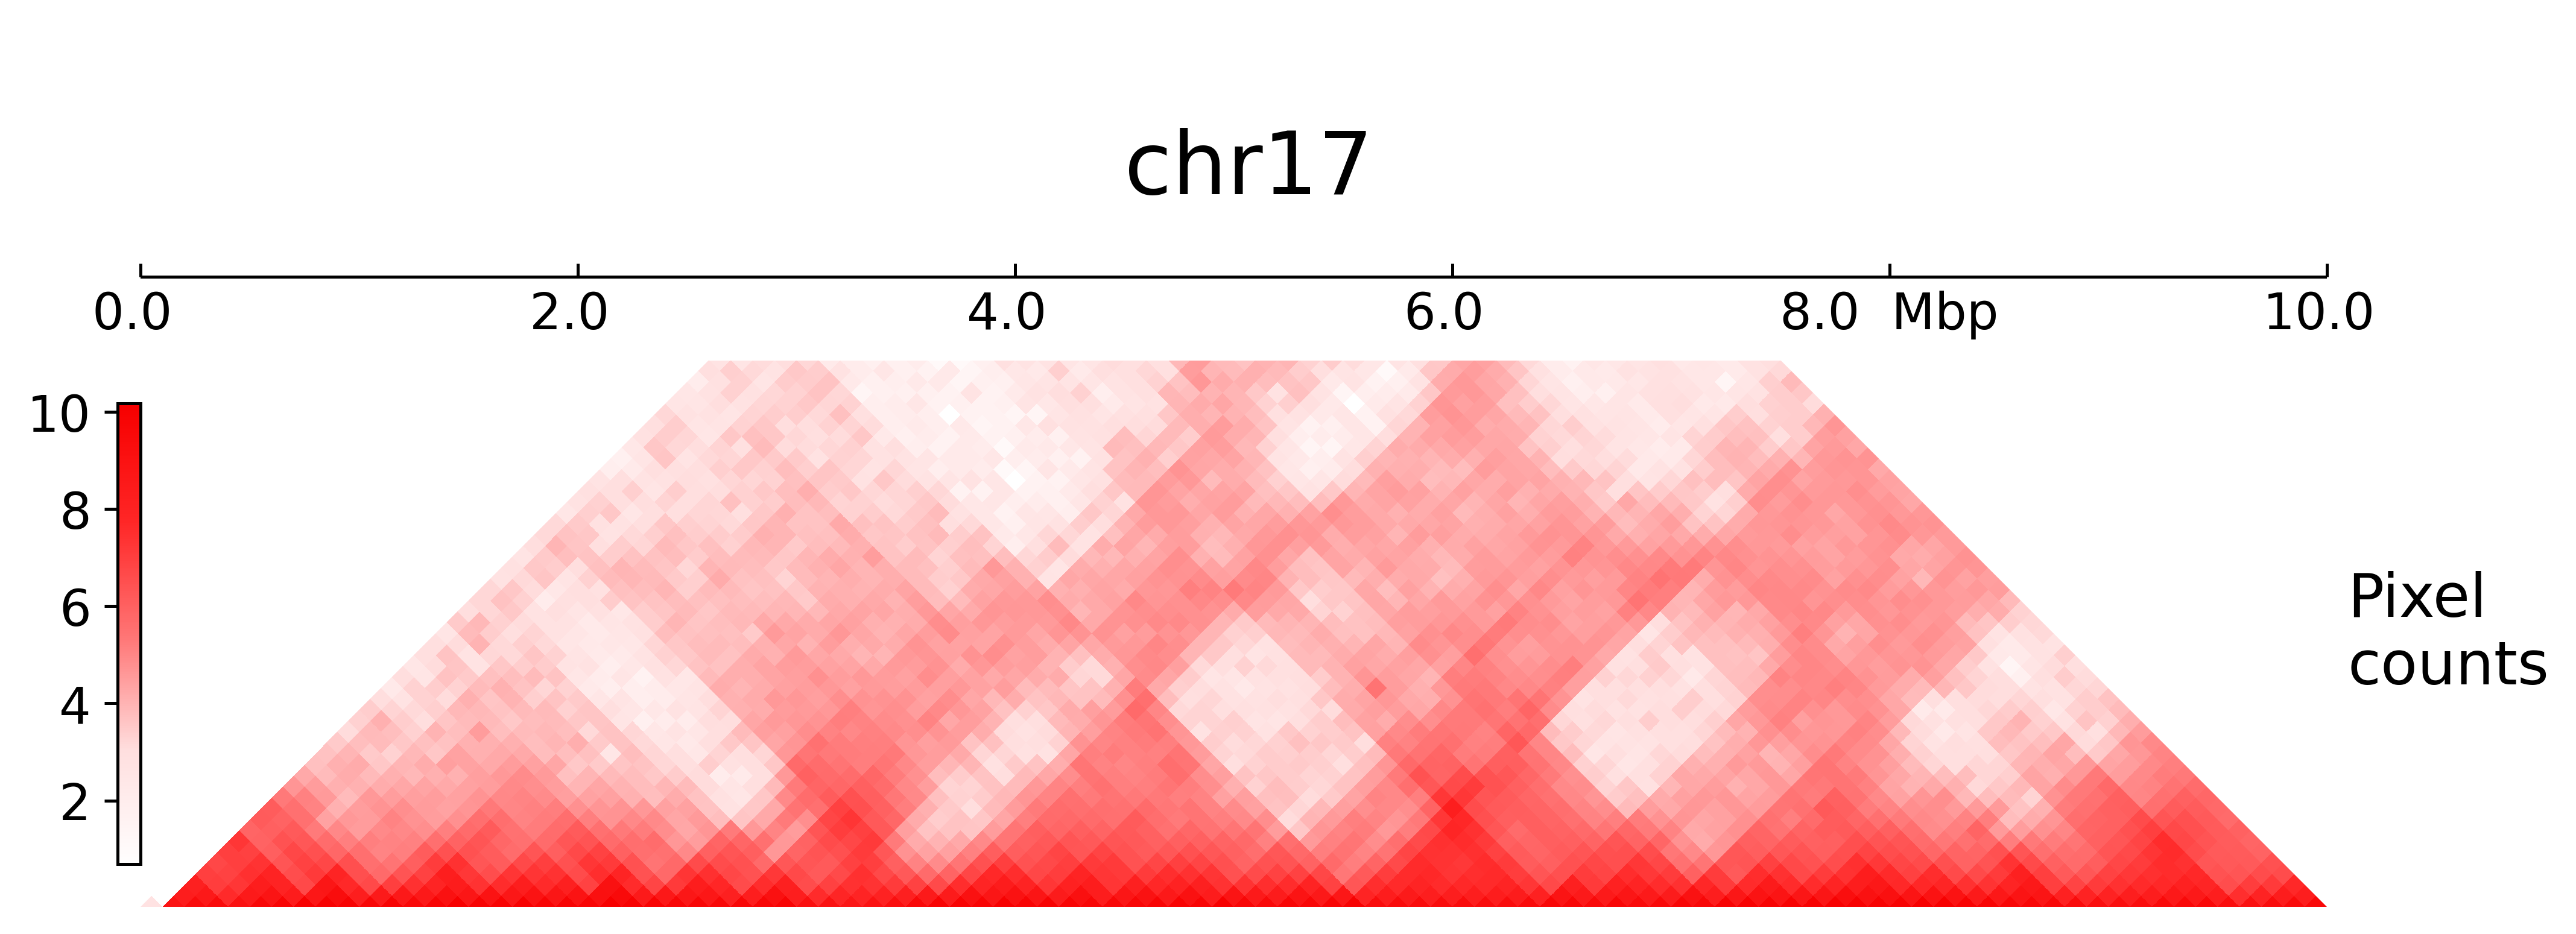

In [3]:
hp.plot_table(table, REGION, modality="triangular", depth_ratio=0.5)

This can be further customized by plotting any valid numeric column in the pixel table or by adding any user defined `coolbox.Track` (either from `coolbox` itself or those provided by HiCONA). As an example, this is how you would plot the edge probabilities of the pixels (obtained after network clustering) as well as the long non-coding RNA genes in the region.

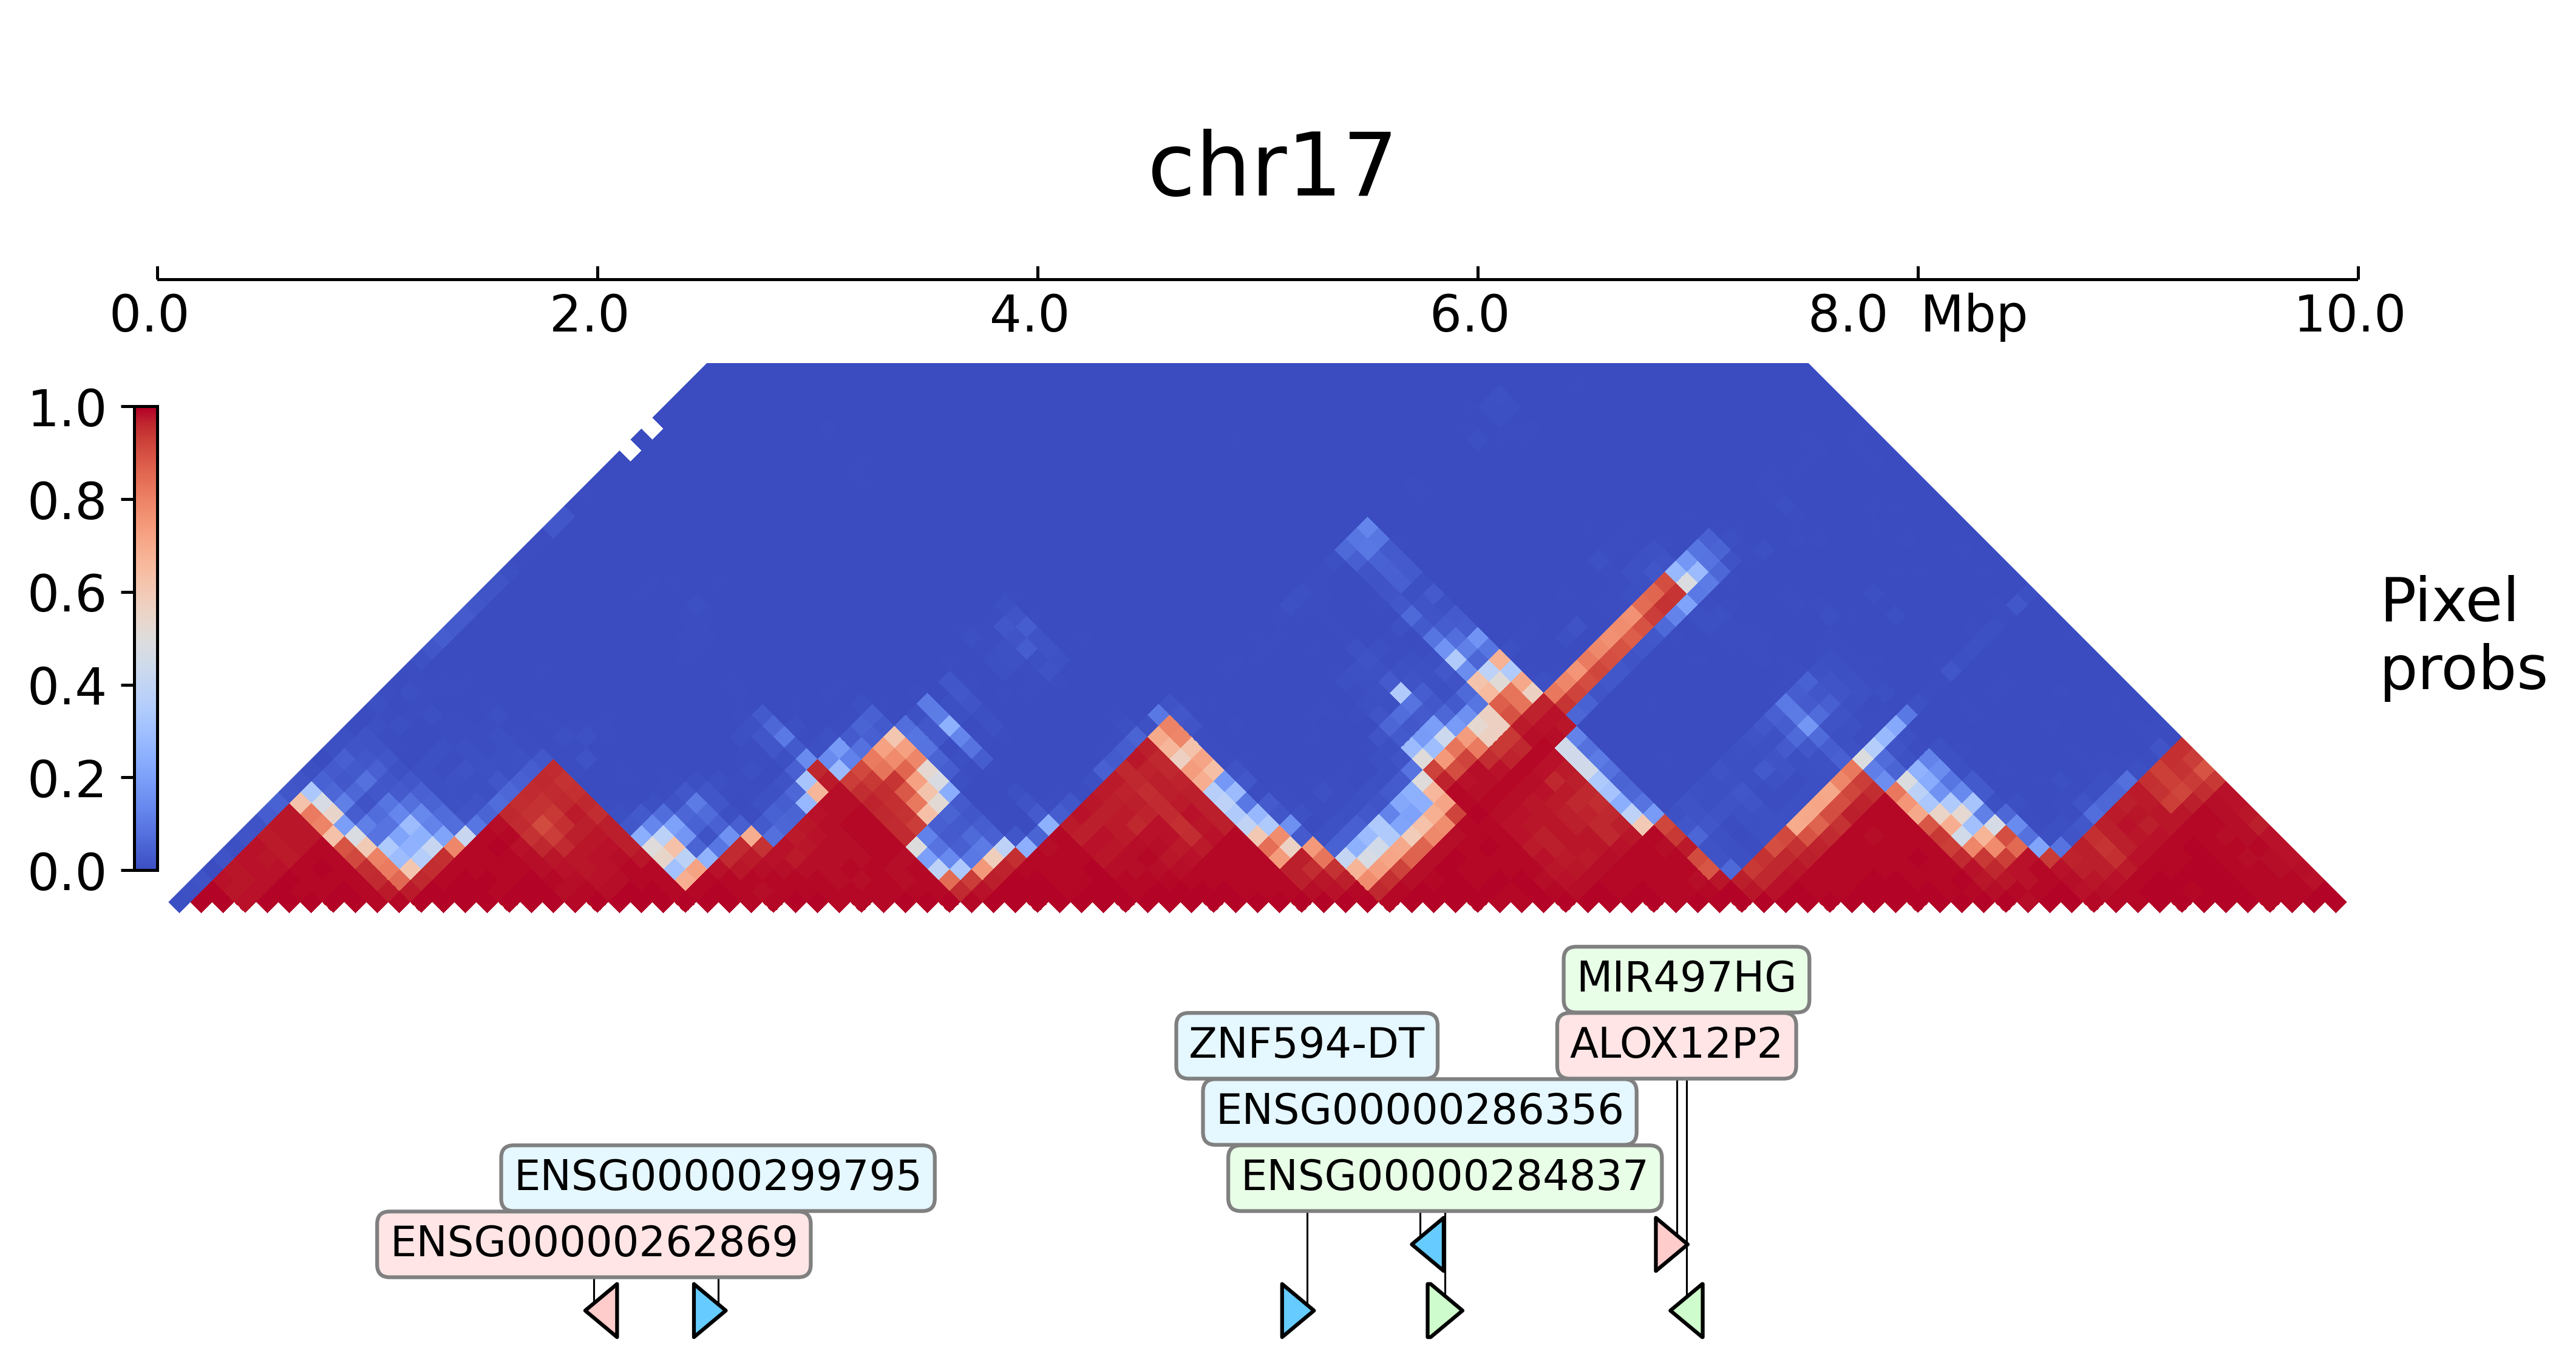

In [4]:
hp.plot_table(
    table, 
    REGION, 
    modality="triangular",
    depth_ratio=0.5,
    value_col="pix_prob",
    tracks=ca.GTF("../data/gencode.v47.long_noncoding_RNAs.chr17.gtf.gz")
)

## Comparison Plotting

Another common operation is to visually compare two matrices, which might mean:

- Same file processed in different ways
- Same region from files representing different biological conditions
- Different columns from the same pixel table (e.i. counts and pixel probabilites)

Regardless of which of these cases (or of the many other possibile ones) you fall in, HiCONA addresses these with `plot_comparison`. This function relies on 2 main parameters, `tables` and `value_cols`. You can either provide:

- one `PixelTable` instance and multiple column names: in this case the plot will contain one contact matrix for each value column of the same table
- multiple `PixelTable` instances and one column name: in this case the plot will contain one contact matrix for each table filled with values from the provided column

The style of these matrices is set to `window` by default. Also, if only two total matrices are plotted, the second one will be plotted upside-down to simplify the comparison.

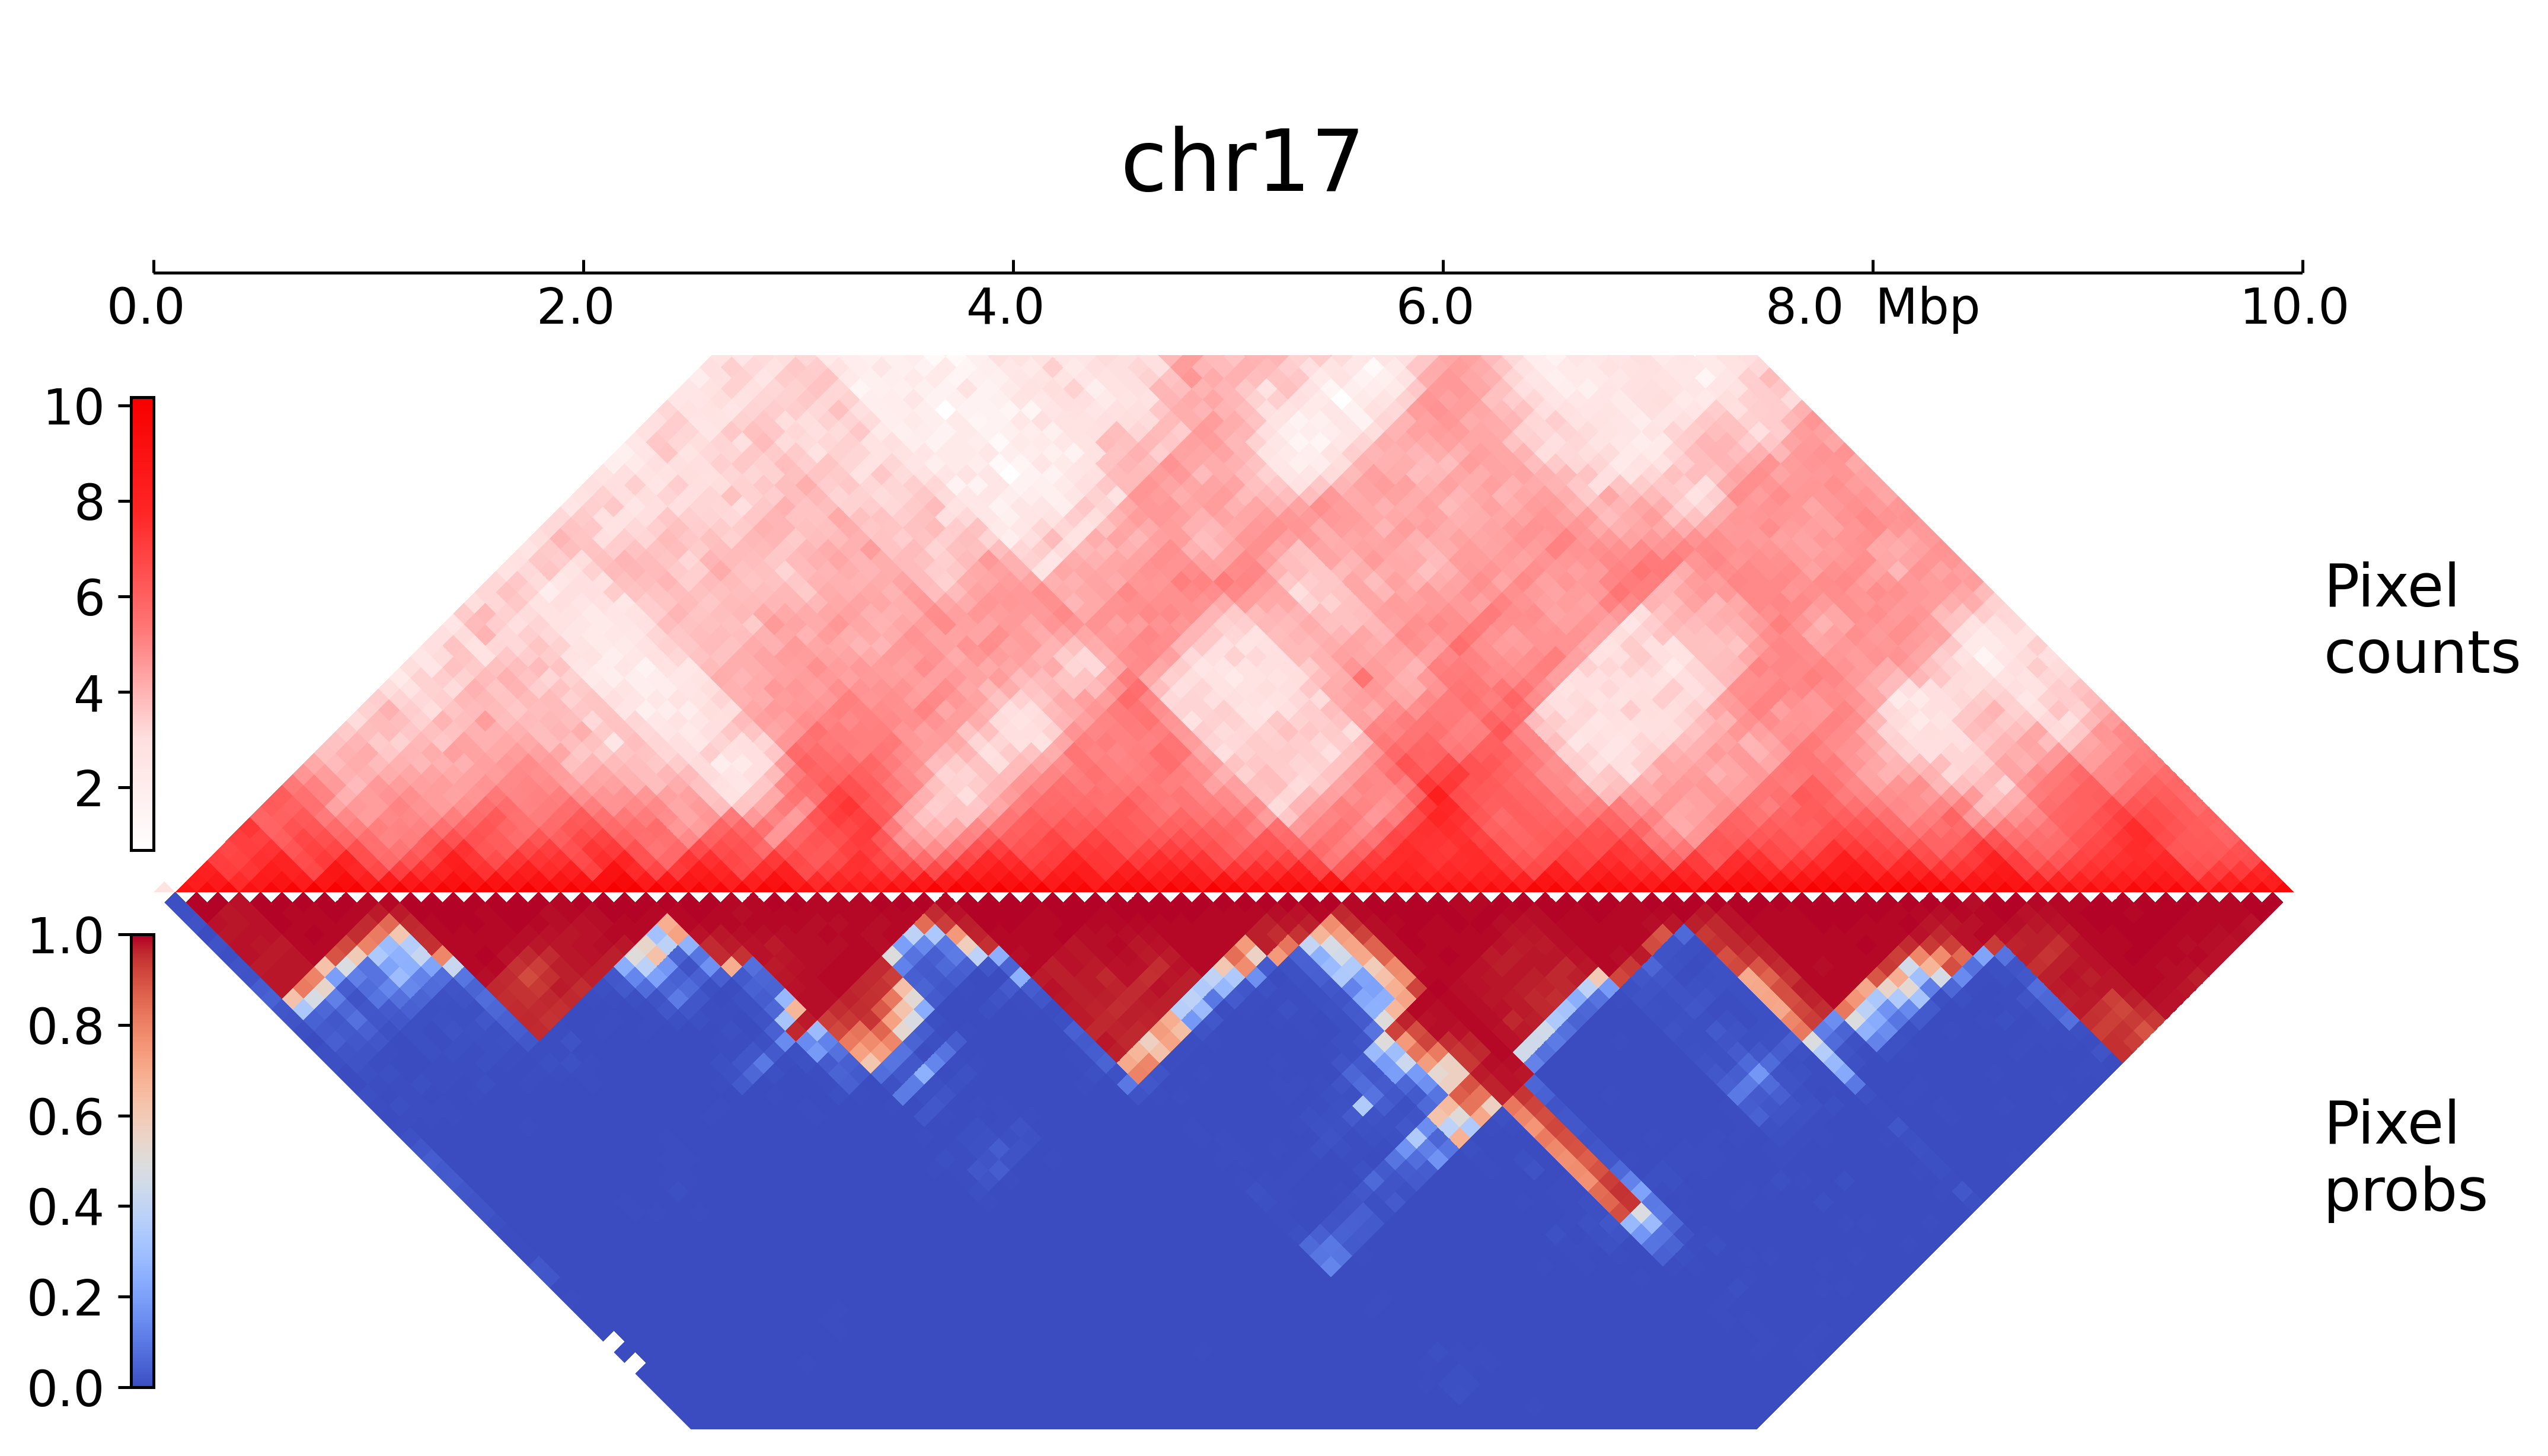

In [5]:
hp.plot_comparison(table, REGION, value_cols=["count", "pix_prob"])

<div class="alert alert-info">

Note

`plot_comparison` currently tries to infer the type of the provided columns. This is needed to decide palette, track name and others. If the column name format is not recognized, an error is raised. If you need those tracks, manually create and add them via the `tracks` parameter.
</div>

Like before, this plot can be customized adding new tracks or tweaking the depth ratio (by default `0.5`).

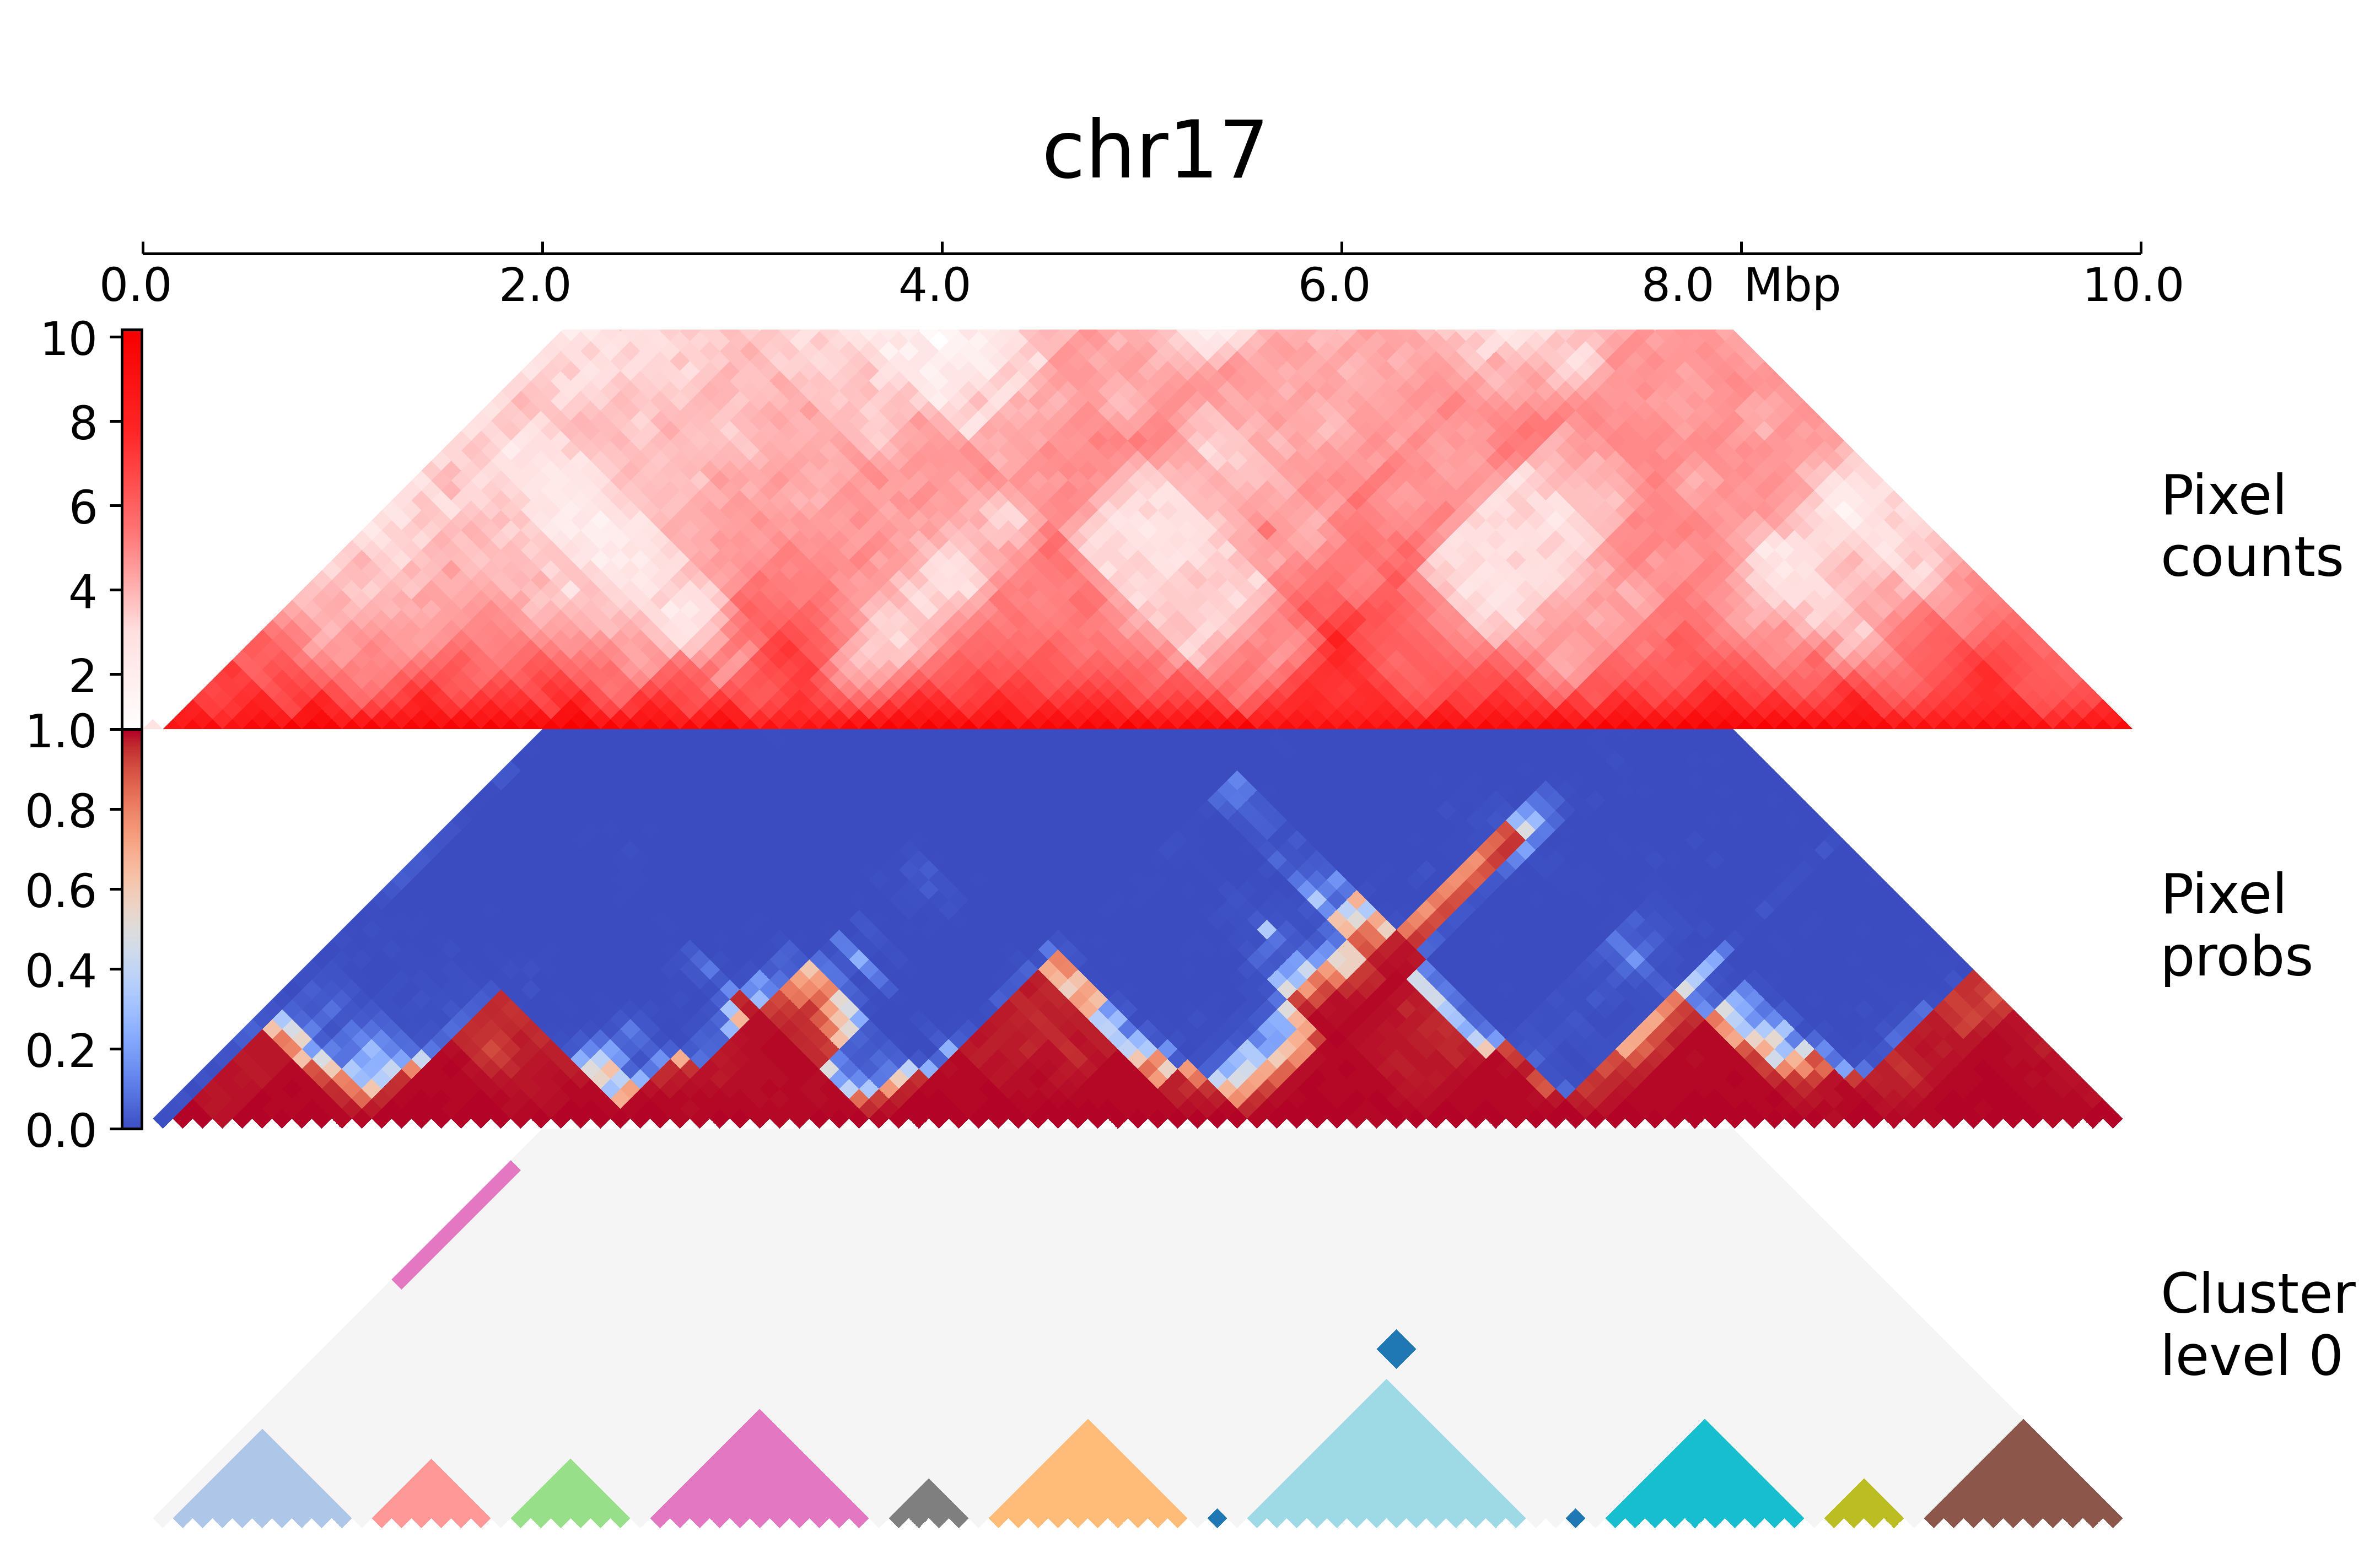

In [6]:
hp.plot_comparison(table, REGION, value_cols=["count", "pix_prob", "level_(0)"], depth_ratio=0.4)

## Clustering Plotting

Given how important clustering is for HiCONA, it is a given that a function for plotting clustering levels is provided. Teh minimum requirement for this function is a `PixelTable` instance on which clustering has already been performed. Then, more parameters can be provided to customize clustering display further: 

- `min_level` and `max_level`, which regulate the lowest and highest level of the hierarchy to plot (extrema included)
- `modality`, which regulates whether clusters are shown at bin or pixel level
- `depth_ratio`, which, just like before, regulates the fraction of the height of the contact matrices to show
- `tracks`, for additional tracks

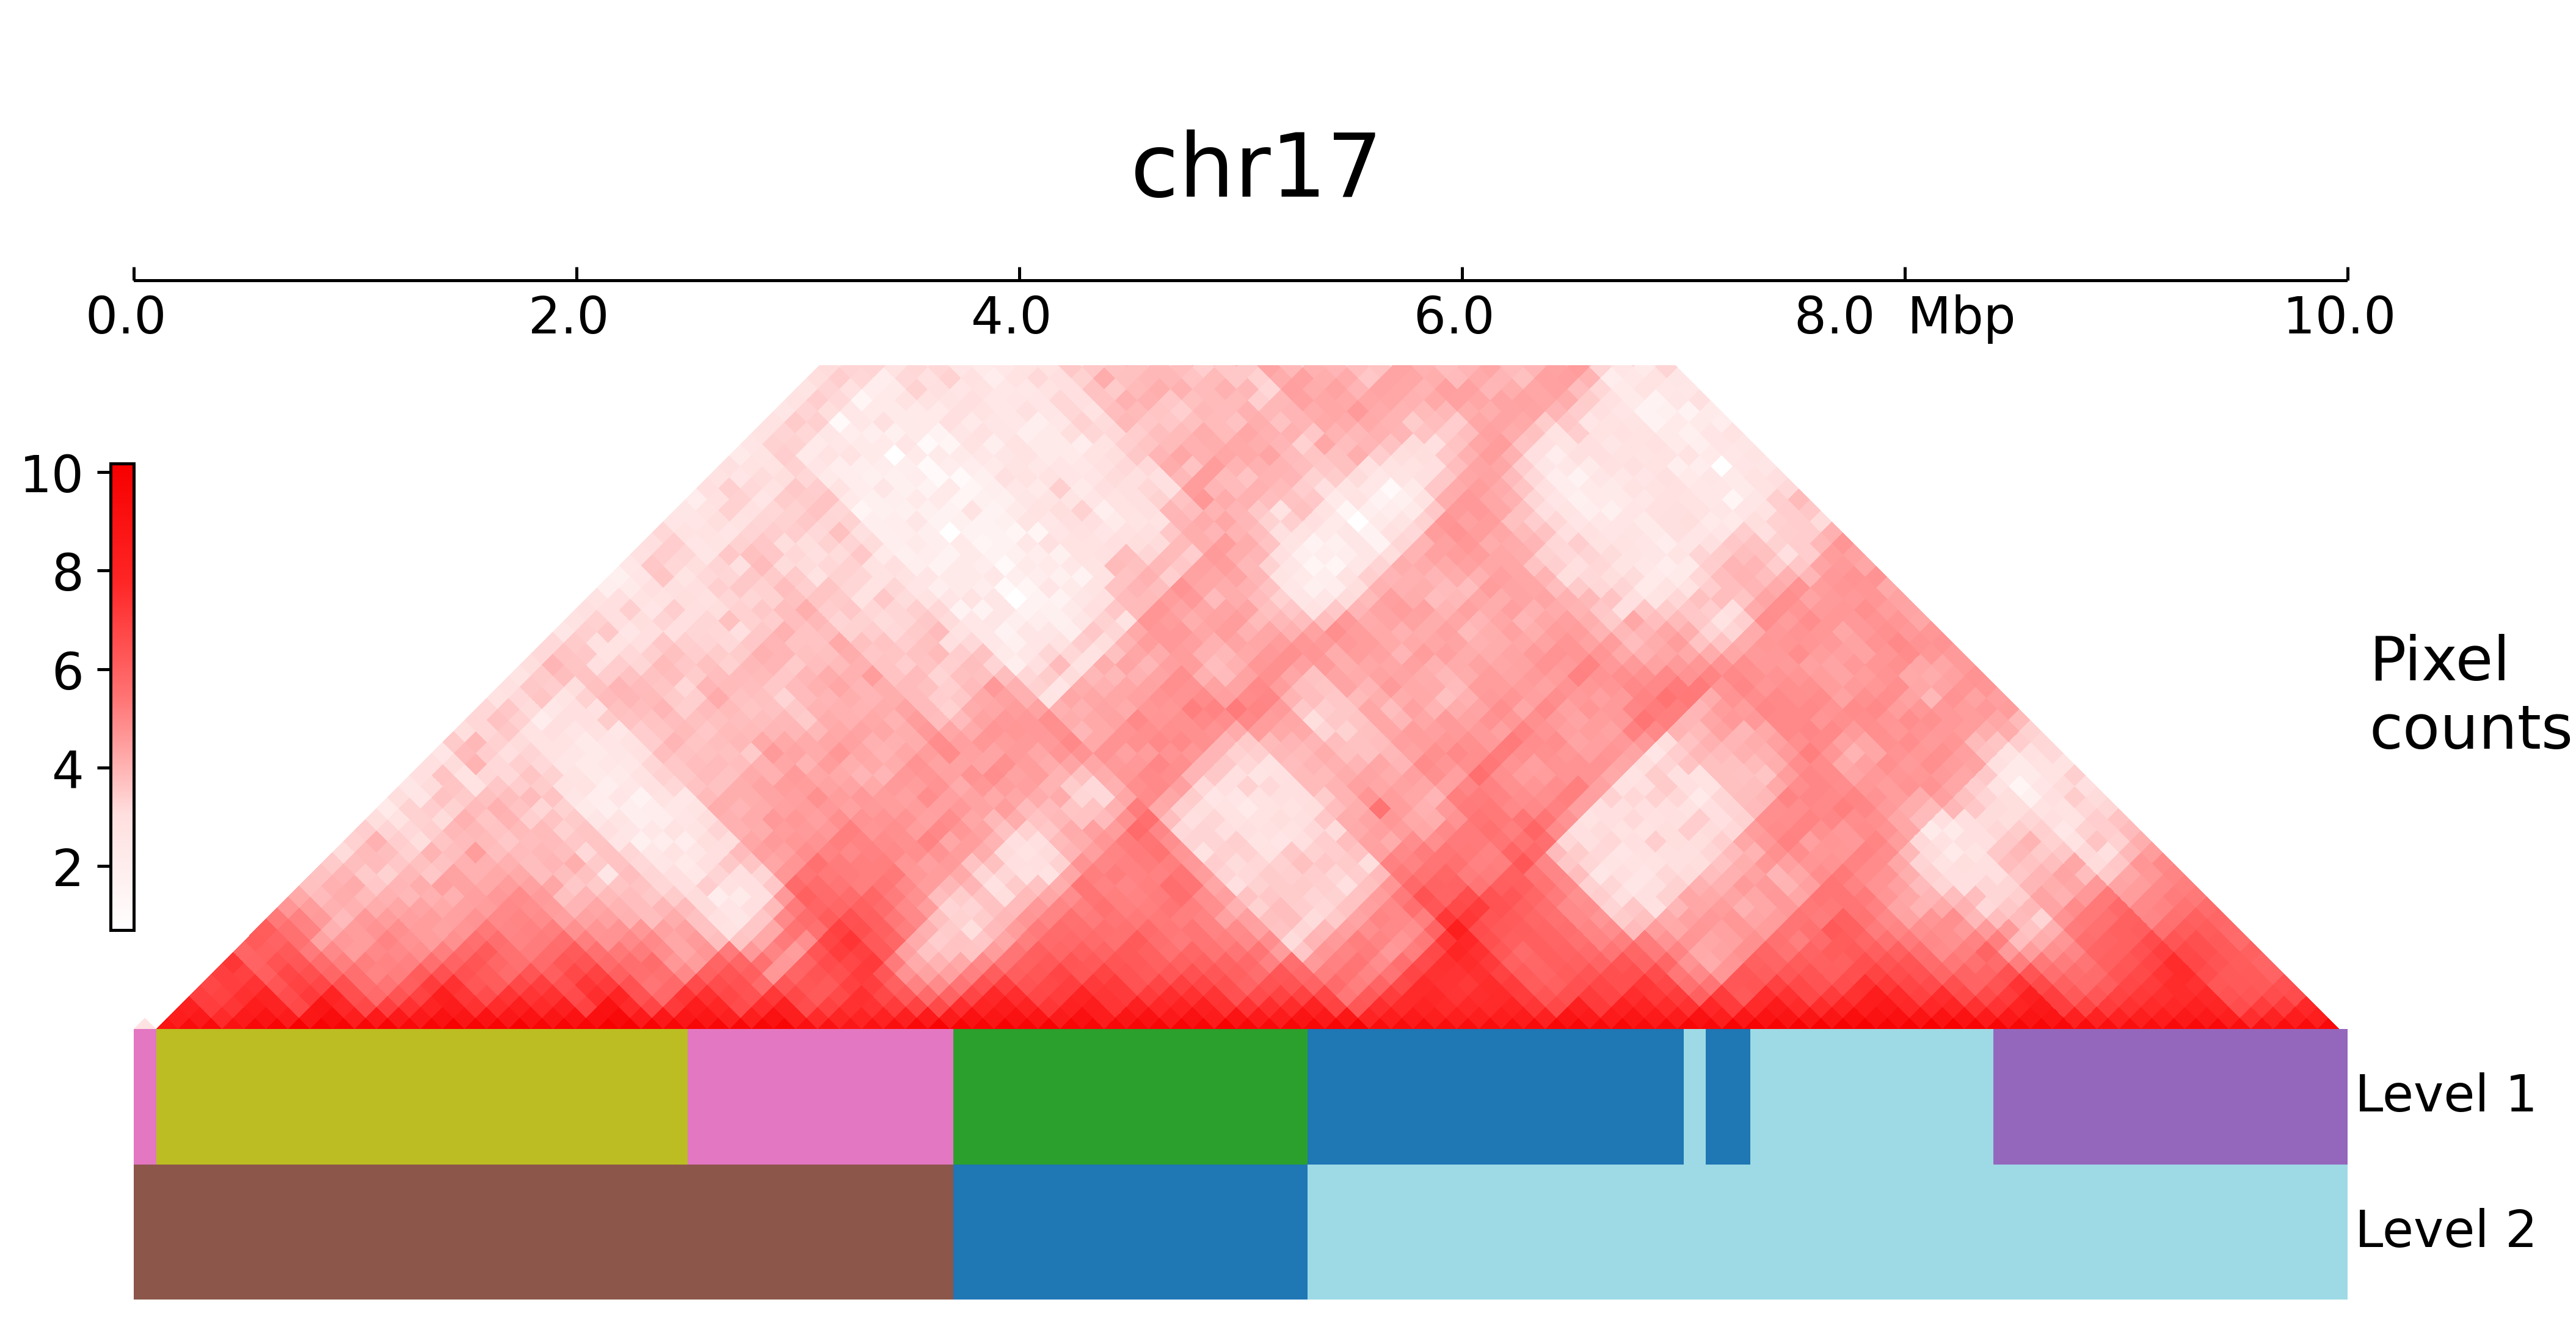

In [7]:
hp.plot_clustering(table, REGION, modality="bins", min_level=1, depth_ratio=0.6)

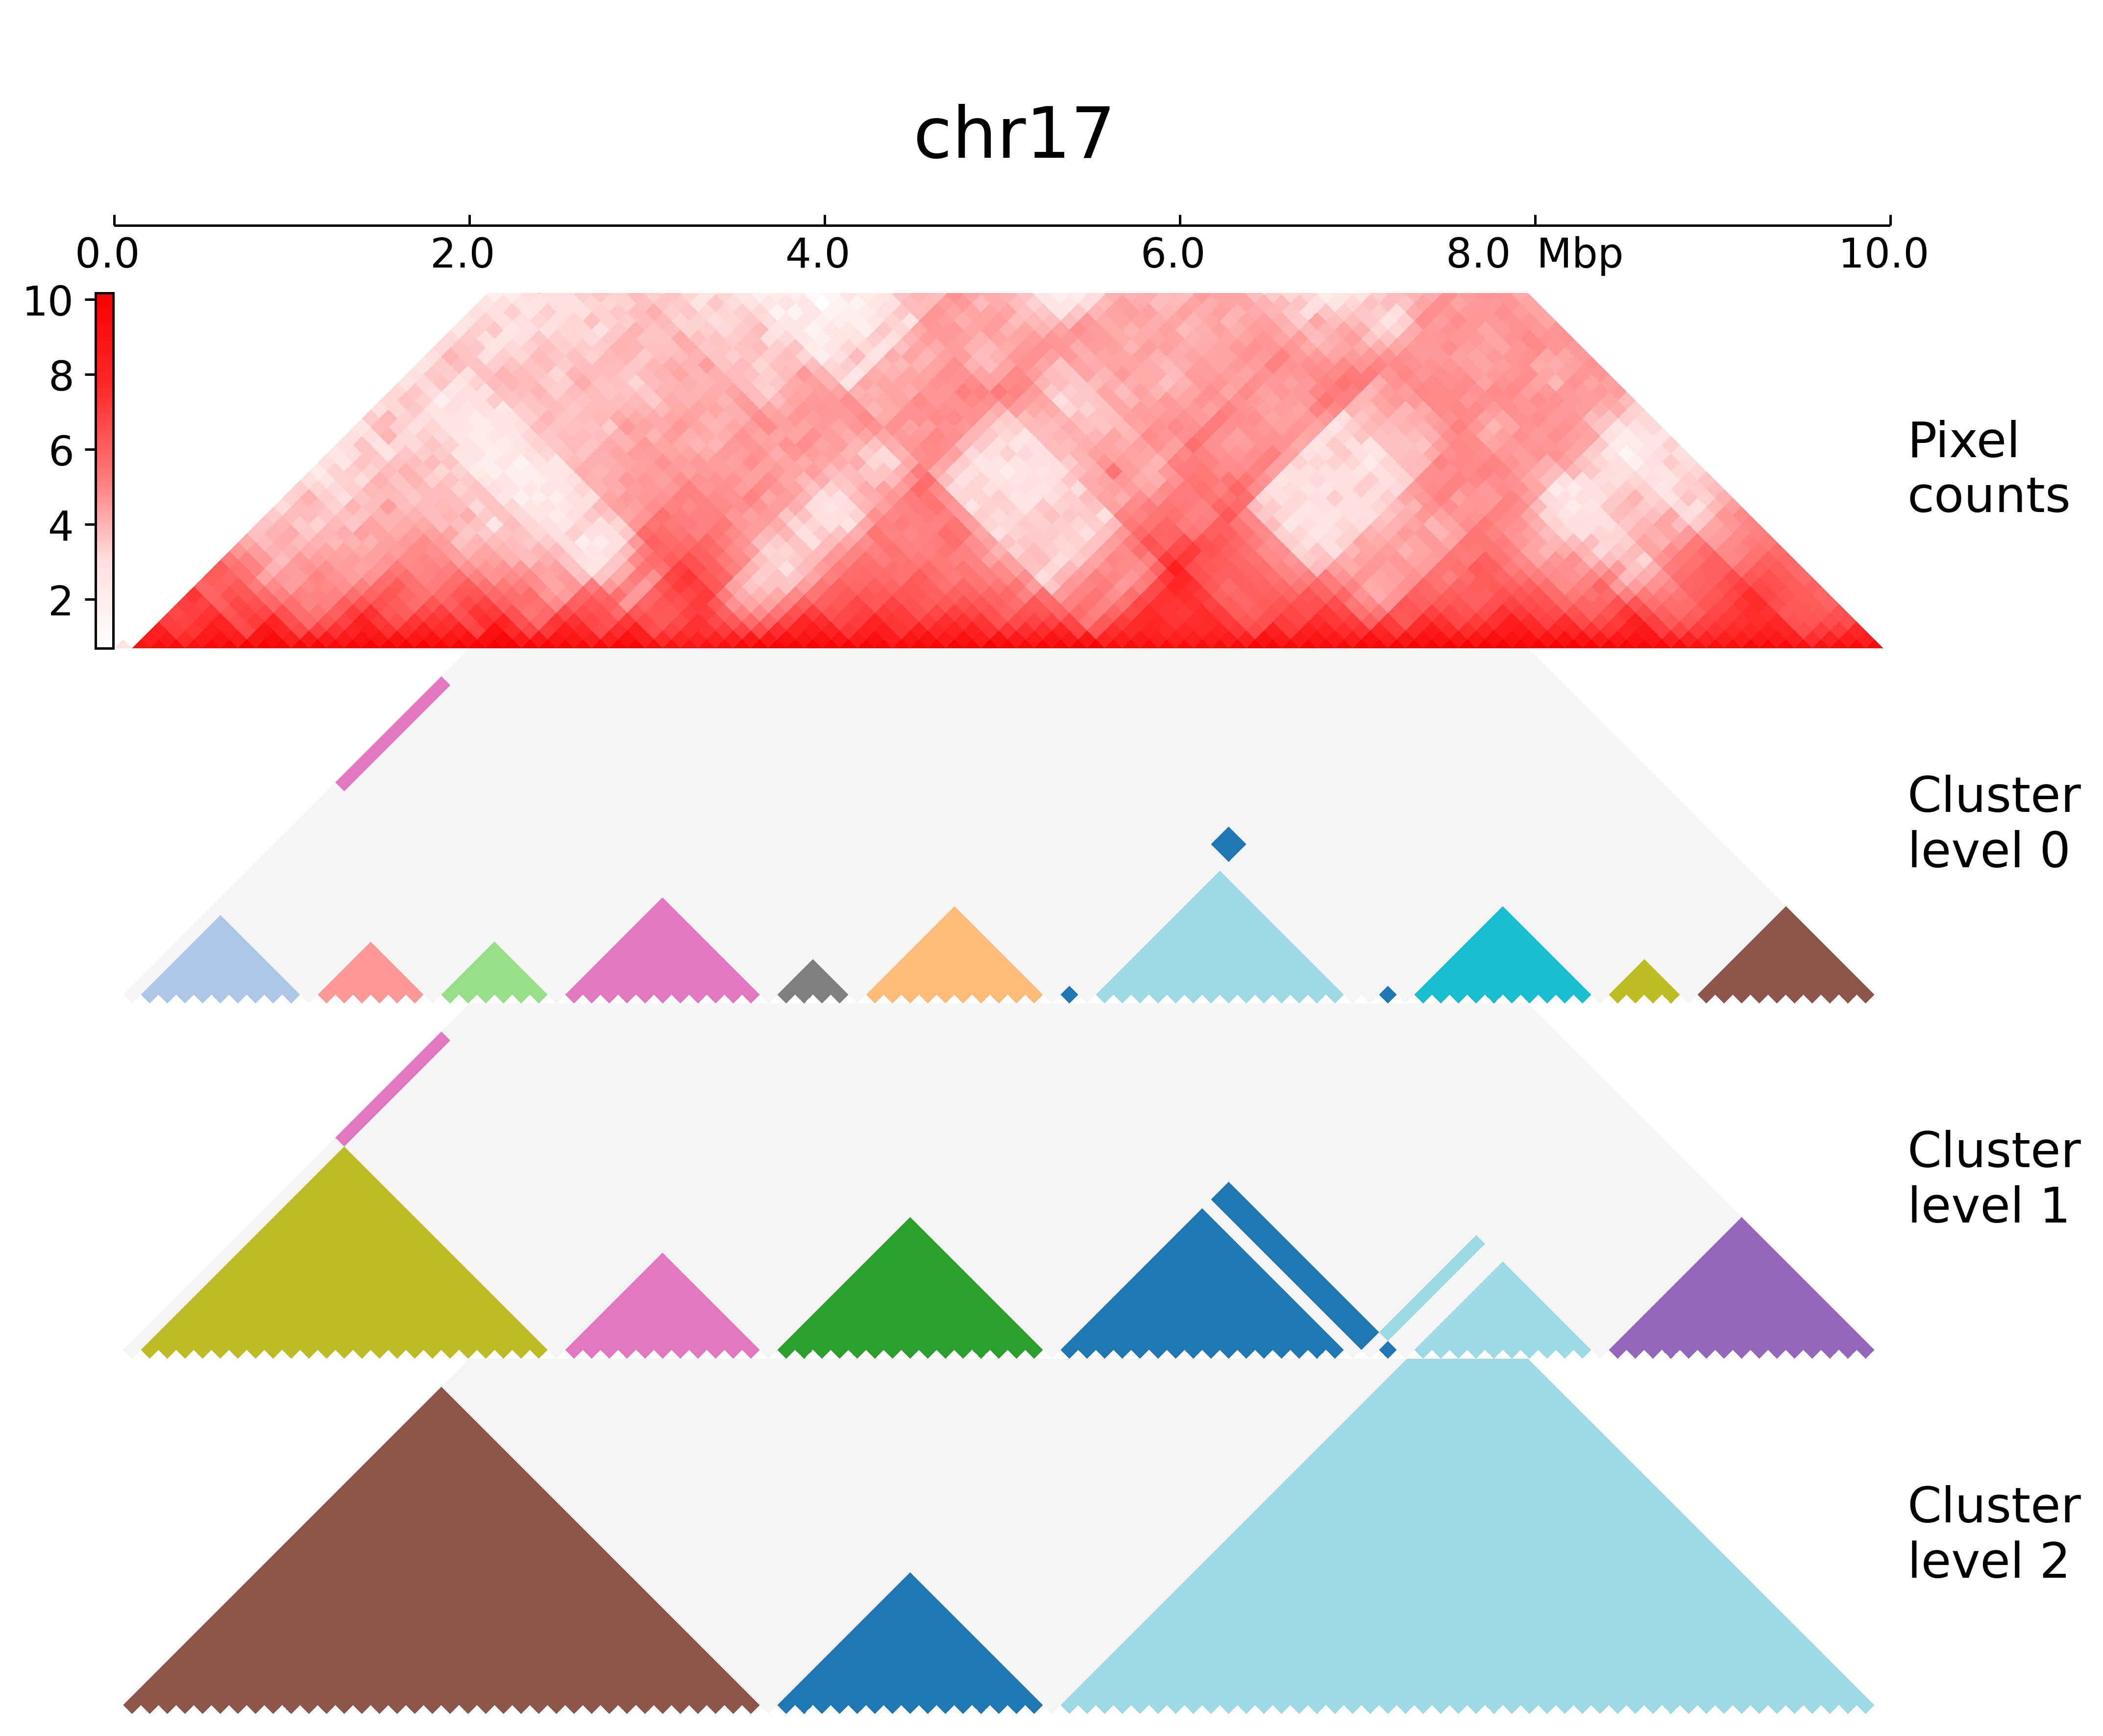

In [8]:
hp.plot_clustering(table, REGION, modality="pixels", depth_ratio=0.4)

## Saving Plots

All plotting functions from HiCONA return the image as a `matplotlib` figure for convenient visualization in a notebook. To save the image, simply pass the desired file name to the `path` parameter of the plotting function. Since saving is done through `matplotlib`, the specified
extension will define which file format the image will be (`.svg`, `.png`...). Note that, by default, the content of the contact matrices is rasterized, regardless of file format; this is to prevent extrememly heavy pictures which could not be loaded in any editing software for assembling panels or adjusting text sizes.

The plotting functions provided by hicona also come with other two quality of life parameters, `width` and `style`.

As you might imagine, `width` is use to set the width of the entire plot in centimeters. This includes all labels and spacers. `height` is not a parameter since it is constrained by the width of the plot in order to ensure that matrices have an equal aspect ratio and do not get distorted. To somewhat adjust the height of the plot, use the `depth_ratio` parameter when available. This way of setting figure size makes it easier to obtain images which can be easily assembled into a predefined panel structure.

Another convenient aspect of HiCONA is the possibility to specify a `style`. Styles are sets of directives regarding the plotting style to use, especially font sizes, saved in [mplstyle](https://matplotlib.org/stable/users/explain/customizing.html#using-style-sheets) format. The objective of these styles is to preventively format the elements of your plot according to your need, trying to reduce the need for manual editing. Currently, HiCONA provides two styles:

- `slides` (default): bigger fonts, wider images
- `publication`: smaller fonts, narrower images

You can use your own style by providing the path to a valid `.mplstyle` file. Default HiCONA styles come with a default width which can be overridden by explicitely passing one to the `width` parameter. Specifying a width is not optional when using a custom style.

<div class="alert alert-info">

Note

Due to jupyter enlarging pictures when showing them, it might look like changing style does not affect the plot. In order to see what the image actually looks like, save it to file and open it directly.
</div>

In [9]:
%%capture
hp.plot_table(table, REGION, modality="triangular", depth_ratio=0.5, style="publication", path="../data/publication.svg")
hp.plot_table(table, REGION, modality="triangular", depth_ratio=0.5, style="slides", path="../data/slides.svg")

Then, by loading the images in a markdown cell we can appreciate the difference.

*Publication image*

<img src="../data/publication.svg" alt="Publication Image" />

*Slides image*

<img src="../data/slides.svg" alt="Slides Image" />